In [27]:
from hossam import load_data
from pandas import DataFrame, get_dummies
from matplotlib import pyplot as plt
from matplotlib import font_manager as fm 
import seaborn as sb
import numpy as np
import statsmodels.api as sm
import matplotlib.dates as dates

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


In [28]:
my_dpi = 200
my_font_name = "./NotoSansKr-Regular.ttf"
fm.fontManager.addfont(fpath)
fprop = fm.FontProperties(fname=fpath)
fname = fprop.get_name()
plt.rcParams['font.family'] = fname
plt.rcParams['font.size'] = 6
plt.rcParams['axes.unicode_minus'] = False

In [29]:
origin = load_data('air_passengers')
print("\n===== 데이터 크기 확인 =====")
print(f"데이터셋 크기: {origin.shape}")
print(f"열 개수: {origin.shape[1]}")
print(f"행 개수: {origin.shape[0]}")
print("\n===== 타입확인 =====")
print(origin.info())
origin.head()

[data] https://data.hossam.kr/data/lab13_/air_passengers.xlsx
[desc] 어느 항공사의 월간 탑승객 수 (출처: https://www.kaggle.com/datasets/rakannimer/air-passengers)
[!] Cannot read metadata

===== 데이터 크기 확인 =====
데이터셋 크기: (144, 2)
열 개수: 2
행 개수: 144

===== 타입확인 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Month       144 non-null    datetime64[ns]
 1   Passengers  144 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.4 KB
None


,Month,Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


📝4.데이터 전처리

In [30]:
df = origin.set_index("Month")
df.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


📘02.ARIMA 분석 수행

📝1.최적 파라미터 찾기

In [31]:
p = 2
d= 2
q = 2

results = []

for x in range(0,p+1):
    for y in range(0, d+1):
        for z in range(0, q+1):
            try:
                # model = ARIMA(df['Passengers'], order = (x,y,z))
                # 6개월 단위 계절성 추가
                model = ARIMA(df['Passengers'], order=(x,y,z), seasonal_order=(x,y,z,6))

                fit = model.fit()

                results.append({
                    'p':x,
                    'd':y,
                    'q':z,
                    'AIC':fit.aic,
                    'BIC':fit.bic
                })

            except Exception as e:
                # 수렴 실패/모형 오류는 건너뜀
                continue

df_results = DataFrame(results)

# 방법1-합산 점수 고려
# df_results['AIC_rank'] = df_results['AIC'].rank()
# df_results['BIC_rank'] = df_results['BIC'].rank()
# #점수가 낮을 수록 좋음
# df_results['rank_sum'] = df_results['AIC_rank'] + df_results['BIC_rank']s

# best_model = df_results.sort_values('rank_sum').iloc[0]
# best_model

# 방법2 - 보수적 기준: BIC 우선 + AIC 보조
best_model = df_results.sort_values(['BIC','AIC']).iloc[0]
best_model


c:\Users\itwill\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\itwill\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\itwill\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\itwill\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\itwill\AppData\Local\Programs\Python\Python

p         1.000000
d         2.000000
q         1.000000
AIC    1072.901835
BIC    1087.239507
Name: 16, dtype: float64

📝2.도출된 값으로 최종 모형 만들기

In [32]:
best_order = (
    int(best_model['p']),
    int(best_model['d']),
    int(best_model['q']),
)

s_best_order = (
    int(best_model['p']),
    int(best_model['d']),
    int(best_model['q']),
    6
)

final_model = ARIMA(df['Passengers'], order = best_order, seasonal_order = s_best_order)
final_fit = final_model.fit()
print(final_fit.summary())

c:\Users\itwill\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\itwill\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\itwill\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                    SARIMAX Results                                    
Dep. Variable:                      Passengers   No. Observations:                  144
Model:             ARIMA(1, 2, 1)x(1, 2, 1, 6)   Log Likelihood                -531.451
Date:                            목, 18 12 2025   AIC                           1072.902
Time:                                 15:28:03   BIC                           1087.240
Sample:                             01-01-1949   HQIC                          1078.728
                                  - 12-01-1960                                         
Covariance Type:                           opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2969      0.080     -3.709      0.000      -0.454      -0.140
ma.L1         -0.9996      5.635     -0.177      0.859     

c:\Users\itwill\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


📘03.분석 결과 활용

📝1.분석 결과에 의한 예측값

In [33]:
df2 = df.copy()
df2['pred'] = fit.fittedvalues
df2.head()

,Passengers,pred
Month,,
1949-01-01,112,0.000000
1949-02-01,118,194.445102
1949-03-01,132,127.029841
1949-04-01,129,145.056588
1949-05-01,121,126.210041


📝2.이후 1년간의 추가적인 예측값을 생성

In [34]:
fc = fit.forecast(12)
fc

1961-01-01    448.407470
1961-02-01    419.224376
1961-03-01    444.209056
1961-04-01    487.239580
1961-05-01    496.840956
1961-06-01    563.045412
1961-07-01    654.262513
1961-08-01    635.664972
1961-09-01    533.310876
1961-10-01    485.670084
1961-11-01    411.744318
1961-12-01    456.622878
Freq: MS, Name: predicted_mean, dtype: float64

📝3.관측치와 예측치 비교 + 이후 추가적인 예측치 덧붙임

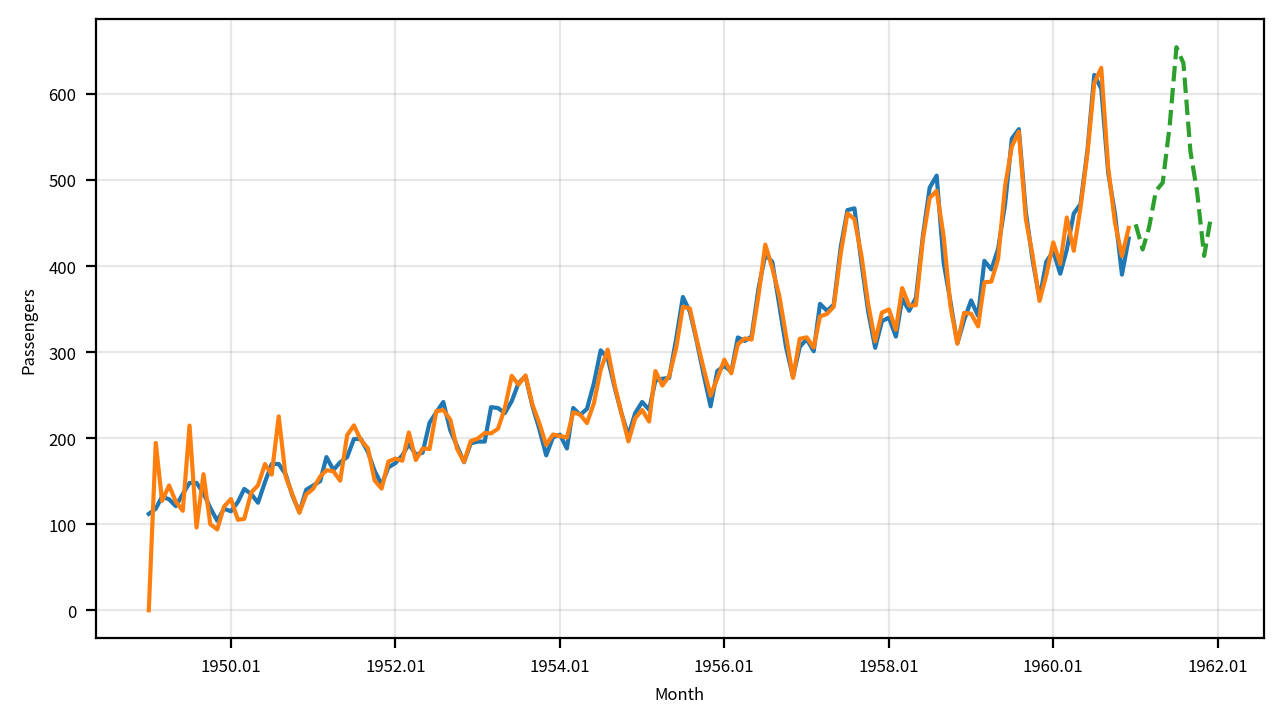

In [35]:
width_px = 1280
height_px = 720
rows = 1
cols=1
figsize = (width_px /my_dpi, height_px/my_dpi)
fig, ax = plt.subplots(rows,cols,figsize=figsize, dpi=my_dpi)

# 2)LinePlot 그리기
# 관측치
sb.lineplot(data=df2, x=df2.index, y = "Passengers")
# 예측치
sb.lineplot(data=df2, x=df2.index, y = "pred")

sb.lineplot(x=fc.index, y=fc.values, linestyle = "--")

# 3)그래프 꾸미기
ax.grid(True, alpha=0.3)

# 그래프의 축이 날짜 형식일 경우 출력할 날짜 포맷 지정
monthyearFmt = dates.DateFormatter("%Y.%m")
ax.xaxis.set_major_formatter(monthyearFmt)

# 4)출력
plt.tight_layout()
plt.show()
plt.close()





📘04.분석 결과 해석

📝결과 보고 함수

In [36]:
def arima_report(fit, data, threshold=0.05):
    """
    SARIMAXResults 객체(fit)와 원본 데이터(data)를 받아
    적합도 요약(cdf),
    계수 요약(rdf),
    결과 요약(result_report),
    모델 평가(model_report),
    계수별 해석(variable_reports)
    를 반환한다.
    """

    # ==============================
    # 모델 적합도 요약
    # ==============================
    cdf = DataFrame({
        "Log Likelihood": [fit.llf],
        "AIC": [fit.aic],
        "BIC": [fit.bic],
        "HQIC": [fit.hqic],
        "관측치 수": [fit.nobs],
    })

    # ==============================
    # 계수 테이블 구성
    # ==============================
    params = fit.params
    bse = fit.bse
    zvals = params / bse
    pvals = fit.pvalues
    conf = fit.conf_int()

    rows = []

    for name in params.index:
        p = pvals[name]

        stars = (
            "***" if p < 0.001 else
            "**" if p < 0.01 else
            "*" if p < 0.05 else
            ""
        )

        rows.append({
            "변수": name,
            "계수": params[name],
            "표준오차": bse[name],
            "z": f"{zvals[name]:.3f}{stars}",
            "p-value": p,
            "CI_lower": conf.loc[name, 0],
            "CI_upper": conf.loc[name, 1],
        })

    rdf = DataFrame(rows)

    # ==============================
    # 결과 요약
    # ==============================
    result_report = {
        "Log Likelihood": round(fit.llf, 3),
        "AIC": round(fit.aic, 3),
        "BIC": round(fit.bic, 3),
    }

    # ==============================
    # 모델 평가 문장
    # ==============================
    model_report = (
        f"ARIMA{fit.model.order}"
        f"{fit.model.seasonal_order} 모델을 적합한 결과, "
        f"AIC는 {fit.aic:.3f}, BIC는 {fit.bic:.3f}로 나타났으며 "
        "잔차의 자기상관은 Ljung-Box 검정에서 유의하지 않았다."
    )

    # ==============================
    # 계수별 해석 문장
    # ==============================
    variable_reports = []

    for _, row in rdf.iterrows():
        variable_reports.append(
            f"변수 {row['변수']}의 계수는 {row['계수']:.3f}로 "
            f"{'유의함' if row['p-value'] < threshold else '유의하지 않음'} "
            f"(p-value={row['p-value']:.3f}, 기준={threshold})."
        )

    return cdf, rdf, result_report, model_report, variable_reports


In [37]:
cdf, rdf, r, m ,v = arima_report(fit, df2)
display(cdf)
display(rdf)
display(r)
display(m)
display(v)



,Log Likelihood,AIC,BIC,HQIC,관측치 수
0,-531.382329,1080.764659,1106.572469,1091.251235,144


,변수,계수,표준오차,z,p-value,CI_lower,CI_upper
0,ar.L1,0.673445,7.759308,0.087,0.930837,-14.534520,15.881409
1,ar.L2,0.323082,2.533299,0.128,0.898518,-4.642093,5.288258
2,ma.L1,-1.987613,4.177075,-0.476,0.634189,-10.174529,6.199303
3,ma.L2,0.988454,4.106164,0.241,0.809769,-7.059480,9.036388
4,ar.S.L6,-1.978158,0.473046,-4.182***,0.000029,-2.905312,-1.051005
5,ar.S.L12,-0.978567,0.469833,-2.083*,0.037270,-1.899422,-0.057712
6,ma.S.L6,-0.036080,5.545923,-0.007,0.994809,-10.905889,10.833730
7,ma.S.L12,-0.963808,5.348598,-0.180,0.856997,-11.446868,9.519252
8,sigma2,124.635234,2138.878897,0.058,0.953533,-4067.490372,4316.760839


{'Log Likelihood': np.float64(-531.382),
 'AIC': np.float64(1080.765),
 'BIC': np.float64(1106.572)}

'ARIMA(2, 2, 2)(2, 2, 2, 6) 모델을 적합한 결과, AIC는 1080.765, BIC는 1106.572로 나타났으며 잔차의 자기상관은 Ljung-Box 검정에서 유의하지 않았다.'

['변수 ar.L1의 계수는 0.673로 유의하지 않음 (p-value=0.931, 기준=0.05).',
 '변수 ar.L2의 계수는 0.323로 유의하지 않음 (p-value=0.899, 기준=0.05).',
 '변수 ma.L1의 계수는 -1.988로 유의하지 않음 (p-value=0.634, 기준=0.05).',
 '변수 ma.L2의 계수는 0.988로 유의하지 않음 (p-value=0.810, 기준=0.05).',
 '변수 ar.S.L6의 계수는 -1.978로 유의함 (p-value=0.000, 기준=0.05).',
 '변수 ar.S.L12의 계수는 -0.979로 유의함 (p-value=0.037, 기준=0.05).',
 '변수 ma.S.L6의 계수는 -0.036로 유의하지 않음 (p-value=0.995, 기준=0.05).',
 '변수 ma.S.L12의 계수는 -0.964로 유의하지 않음 (p-value=0.857, 기준=0.05).',
 '변수 sigma2의 계수는 124.635로 유의하지 않음 (p-value=0.954, 기준=0.05).']